<a href="https://colab.research.google.com/github/mash-bestiya/-/blob/main/%D0%98%D0%90%D0%94_%D0%BF%D1%80_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ИАД - Практика №1 - Выполнила: Горюнова Мария, ББСО-01-24

## ЗАДАНИЕ

Провести полный цикл EDA:
1. Загрузите данные и выведите общую информацию о датафрейме (df.info(), df.shape).
2. Проверьте наличие пропущенных значений и предложите стратегию их обработки (удаление,
заполнение медианой/модой и т.д.).
3. Рассчитайте основные статистики для числовых признаков (df.describe()).
4. Проанализируйте категориальные признаки: постройте частотные таблицы и визуализируйте
распределения (столбчатые диаграммы).
5. Исследуйте взаимосвязи:
Как выживаемость зависит от пола, класса каюты, возраста?
Постройте boxplot возраста по классам и гистограммы выживших/погибших.
Постройте тепловую карту корреляций между числовыми признаками.
6. На основе анализа сформулируйте не менее трёх гипотез о факторах, влияющих на
выживаемость.

In [52]:
#подготовительный этап - загрузим библиотеки и данные Титаника
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="darkgrid") #стиль графиков

df = sns.load_dataset("titanic") #наш датафрейм (df)


Теперь можем провести полный цикл EDA

In [53]:
#1 Загрузите данные и выведите общую информацию о датафрейме (df.info(), df.shape).
print("--- Общая информация (info)---")
df.info()
print()
print("--- Информация по shape ---")
df.shape

--- Общая информация (info)---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Информация по shape ---


(891, 15)

In [54]:
#2 Проверьте наличие пропущенных значений
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [55]:
#2 и предложите стратегию их обработки
# У "deck" слишком много пропусков, можно удалить столбец
df = df.drop(columns=['deck'])

# У "age" тоже пропуски, думаю, можно заполнить медианой, чтобы выбросы не исказили среднее
df['age'] = df['age'].fillna(df['age'].median())

# В "embark_town" тоже есть пробелы, но они незначительные особо, значит можно заполнить самым частым значением (мода)
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# c "embark" аналогично как и с "embark_town"
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

#выведем, что получилось после обработки (на всякий случай)
print(df.isnull().sum())



survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


Теперь нету пропусков

In [56]:
#3 Рассчитайте основные статистики для числовых признаков (df.describe())
display(df.describe())


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,count
sex,
male,577
female,314


/tmp/ipykernel_637/3751024199.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sex", palette="crest")


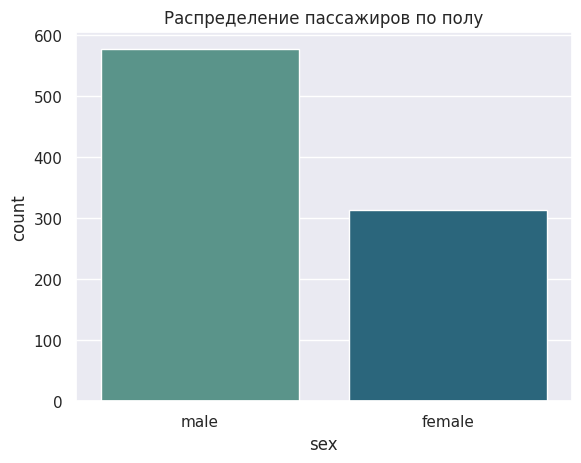

,count
class,
Third,491
First,216
Second,184


/tmp/ipykernel_637/3751024199.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class", palette="viridis")


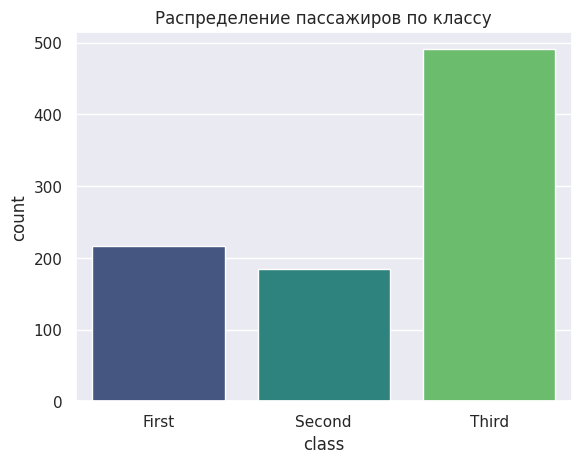

In [57]:
#4 Проанализируйте категориальные признаки: постройте частотные таблицы и визуализируйте распределения (столбчатые диаграммы)

# Посмотрим распределение по полу и классу пассажиров
display(df['sex'].value_counts())

sns.countplot(data=df, x="sex", palette="crest")
plt.title("Распределение пассажиров по полу")
plt.show()

display(df['class'].value_counts())
sns.countplot(data=df, x="class", palette="viridis")
plt.title("Распределение пассажиров по классу")
plt.show()

/tmp/ipykernel_637/1999822272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='age', palette="viridis")


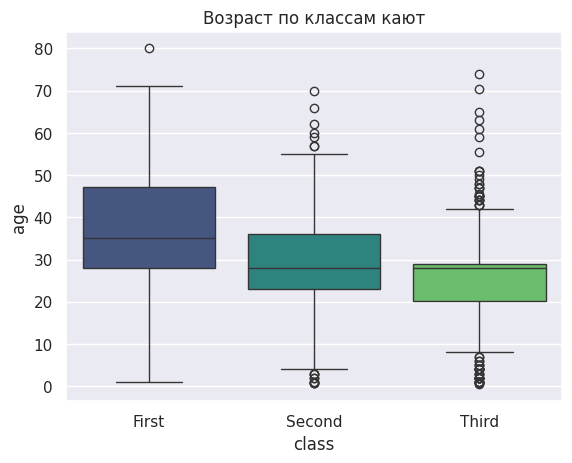

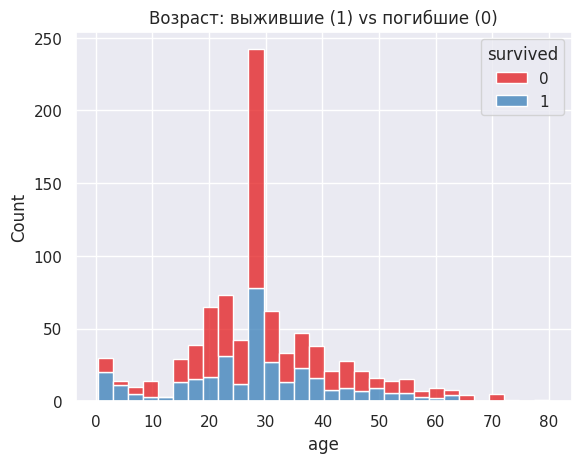

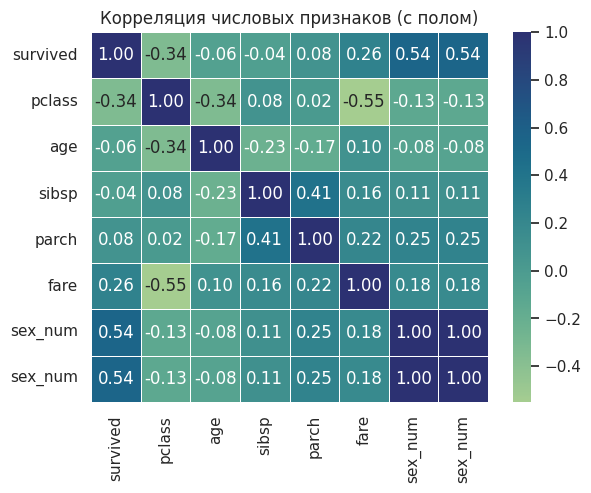

In [69]:
#5 Исследуйте взаимосвязи: Как выживаемость зависит от пола, класса каюты, возраста? Постройте boxplot возраста по классам и гистограммы выживших/погибших. Постройте тепловую карту корреляций между числовыми признаками.
#Boxplot возраста по классам
sns.boxplot(data=df, x='class', y='age', palette="viridis")
plt.title('Возраст по классам кают')
plt.show()

#Гистограмма выживших/погибших по возрасту
sns.histplot(data=df, x='age', hue='survived', multiple='stack', palette='Set1')
plt.title('Возраст: выжившие (1) vs погибшие (0)')
plt.show()

"""Одну из своих гипотез "женщин (и детей) первыми сажали в шлюпки" я решила проверисть через тепловую карту"""

# Кодируем пол: male=0, female=1
df['sex_num'] = df['sex'].map({'male': 0, 'female': 1})

# Тепловая карта с включённым полом
numeric_df = df.select_dtypes(include=['number'])
# Добавляем sex_num в числовые признаки
numeric_df_with_sex = pd.concat([numeric_df, df[['sex_num']]], axis=1)
sns.heatmap(numeric_df_with_sex.corr(), annot=True, cmap='crest', fmt='.2f', linewidths=0.5)
plt.title('Корреляция числовых признаков (с полом)')
plt.show()

*6 На основе анализа сформулируйте не менее трёх гипотез о факторах, влияющих на выживаемость.*

Анализируя наши графики, можно сказать, что у женщин более высокая "выживаемость". Смотрим по тепловой карте пересечение "sex_num" и "survived" положительный коэффициент +0,54 означает,что ближе к 1 = женщина (обозначили женщин за 1). Также есть тенденция выживаемости людей до ~10 лет (см. гистограмму). Это можно даже исторически подтвердить - на Титанике женщин и детей первыми сажали в шлюпки.
Ещё прослеживается такая гипотеза - пассажиры 1-го класса имели больше шансов на выживание. На тепловой карте корреляция между "pclass" и "survived" отрицательная ≈ -0,34. Поскольку 1-й класс кодируется как 1, а 3-й как 3, отрицательная связь означает: чем выше номер класса (ниже статус), тем ниже выживаемость. Это подтверждает, что богатые пассажиры спасались чаще.
